In [ ]:
import pandas as pd
import statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
ChinaBank = pd.read_csv('../data/ChinaBank.csv', index_col ='Date', parse_dates=["Date"], sep=',', na_values=[''], quotechar='"')
ChinaBank.head()

In [ ]:
ChinaBank["diff_1"] = ChinaBank["Close"].diff(1).fillna(0)
ChinaBank["diff_2"] = ChinaBank["diff_1"].diff(1).fillna(0)
ChinaBank.head()
ChinaBank = ChinaBank[["Close","diff_1","diff_2"]]
ChinaBank.plot(subplots=True,figsize=(10,8))
plt.show()

In [ ]:
fig,ax =plt.subplots(2,1,figsize=(12,8))
plot_acf(ChinaBank["Close"],ax=ax[0],lags=40 )
plot_pacf(ChinaBank["Close"],ax=ax[1])
plt.show()

In [ ]:
fig,ax =plt.subplots(2,1,figsize=(12,8))
plot_acf(ChinaBank["diff_1"],ax=ax[0],lags=40 )
plot_pacf(ChinaBank["diff_1"],ax=ax[1])
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
lags = 9
ncols = 3
nrows = int(np.ceil(lags / ncols))

series = ChinaBank["Close"].dropna()
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 4 * nrows)
)
for ax, lag in zip(axes.flat, np.arange(1, lags + 1)):
    lag_str = f"t-{lag}"
    X = pd.concat([series, series.shift(lag)],axis=1)
    X.columns = ["y", lag_str]
    X = X.dropna()
    corr = X.corr().iloc[0, 1]
    X.plot(
        ax=ax,
        kind="scatter",
        x=lag_str,
        y="y"
    )
    ax.set_xlabel(lag_str)
    ax.set_ylabel("Original")
    ax.set_title(f"Lag: {lag_str} (corr={corr:.2f})")
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(12,8))
series = ChinaBank["Close"].dropna()
series.plot(ax=axes[0, 0],title="China Bank")
series.plot(ax=axes[0, 1], kind="hist", bins=25,title="Histogram")
plot_acf(ChinaBank["Close"],axes[1, 0],lags=40 )
plot_pacf(ChinaBank["Close"],axes[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
sub = ChinaBank.loc['2014-01':'2014-06',"Close"]
train = sub.loc['2014-01':'2014-04']
test = sub.loc['2014-05':'2014-06']


In [ ]:
plt.figure(figsize=(12,8))
plt.plot(train)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller as ADF
ChinaBank_ADF = ADF(ChinaBank["Close"])
ChinaBank_DIFF_1_ADF = ADF(ChinaBank["diff_1"])
ChinaBank_DIFF_2_ADF = ADF(ChinaBank["diff_2"])
print("ChinaBank_DIFF_1_ADF:")
print(ChinaBank_DIFF_1_ADF)
print("ChinaBank_DIFF_2_ADF:")
print(ChinaBank_DIFF_2_ADF)
print("ChinaBank_ADF:")
print(ChinaBank_ADF)

In [ ]:
p_min = 0
d_min = 0
q_min = 0
p_max = 5
d_max = 0
q_max = 5

In [ ]:
#Initialize a DataFrame to store the results,，以BIC准则
import itertools
from statsmodels.tsa.arima.model import ARIMA

results_bic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p_min,p_max+1)],
                           columns=['MA{}'.format(i) for i in range(q_min,q_max+1)])

for p,d,q in itertools.product(range(p_min,p_max+1),
                               range(d_min,d_max+1),
                               range(q_min,q_max+1)):
    if p==0 and d==0 and q==0:
        results_bic.loc['AR{}'.format(p), 'MA{}'.format(q)] = np.nan
        continue
    try:
        model = ARIMA(train, order=(p, d, q),)
        results = model.fit()
        results_bic.loc['AR{}'.format(p), 'MA{}'.format(q)] = results.bic
    except Exception as e:
        print(f"ARIMA({p},{d},{q}) failed: {e}")
        continue

In [ ]:
train = sub.loc['2014-01':'2014-03']
test = sub.loc['2014-04':'2014-06']

In [ ]:
results_bic = results_bic[results_bic.columns].astype(float)
results_bic.dtypes

In [ ]:

fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(results_bic,
                 annot=True,
                 fmt='.2f'
                 )
plt.show()

In [ ]:
results_bic.stack().idxmin()

In [ ]:
#Initialize a DataFrame to store the results,，以BIC准则
import itertools
from statsmodels.tsa.arima.model import ARIMA

results_aic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p_min,p_max+1)],
                           columns=['MA{}'.format(i) for i in range(q_min,q_max+1)])

for p,d,q in itertools.product(range(p_min,p_max+1),
                               range(d_min,d_max+1),
                               range(q_min,q_max+1)):
    if p==0 and d==0 and q==0:
        results_aic.loc['AR{}'.format(p), 'MA{}'.format(q)] = np.nan
        continue
    try:
        model = ARIMA(train, order=(p, d, q),)
        results = model.fit()
        results_aic.loc['AR{}'.format(p), 'MA{}'.format(q)] = results.aic
    except Exception as e:
        print(f"ARIMA({p},{d},{q}) failed: {e}")
        continue

In [ ]:
results_aic.stack().idxmin()

In [ ]:
import statsmodels.api as sm
train_diff = train.diff().dropna()
train_results = sm.tsa.arma_order_select_ic(train_diff, ic=['aic', 'bic'], trend='n', max_ar=3, max_ma=3)

print('AIC', train_results.aic_min_order)
print('BIC', train_results.bic_min_order)

In [ ]:
import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

train_diff = train.diff().dropna()

records = []

for p, q in itertools.product(range(0, 5), range(0, 5)):
    try:
        model = ARIMA(
            train_diff,
            order=(p, 0, q),
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        result = model.fit(method_kwargs={"maxiter": 1000})

        records.append({
            "p": p,
            "q": q,
            "aic": result.aic,
            "bic": result.bic,
            "converged": result.mle_retvals.get("converged", None)
        })

    except Exception as e:
        records.append({
            "p": p,
            "q": q,
            "aic": None,
            "bic": None,
            "converged": False,
            "error": str(e)
        })

results_check = pd.DataFrame(records)

results_check

In [ ]:
valid_results = results_check[results_check["converged"] == True]

print("Best AIC:")
print(valid_results.loc[valid_results["aic"].idxmin()])

print("Best BIC:")
print(valid_results.loc[valid_results["bic"].idxmin()])

In [ ]:
p = 1
d = 1
q = 0
model = sm.tsa.ARIMA(train, order=(p, d, q))
results = model.fit()
resid = results.resid

In [ ]:
plot_acf(resid,lags=20)
plt.show()

In [ ]:
predict_sunspots = results.predict(dynamic=False)
print(predict_sunspots)

In [ ]:
plt.subplots(figsize=(10, 8))
plt.plot(predict_sunspots)
plt.plot(train)
plt.show()

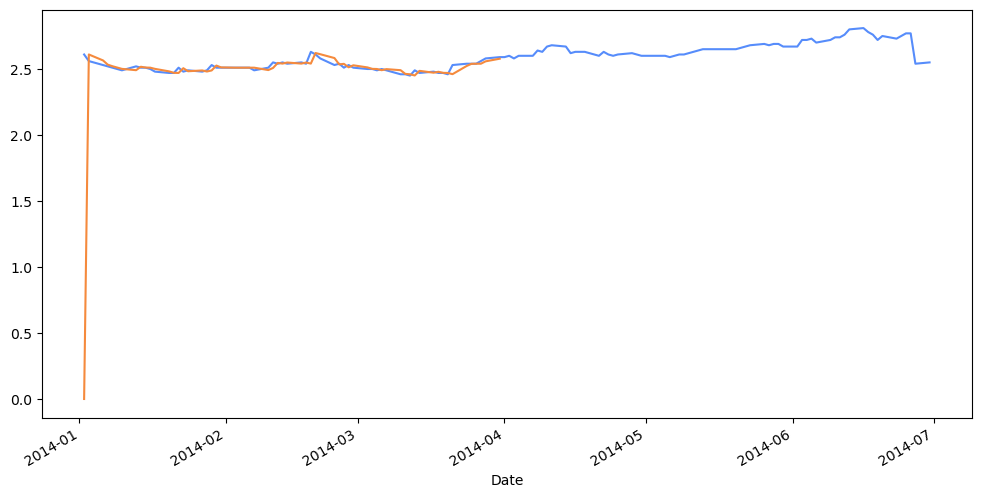

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))
ax = sub.plot(ax=ax)
#预测数据
predict_sunspots.plot(ax=ax)
plt.show()

In [ ]:
pred = results.predict(start=len(train),
    end=len(train) + len(test) - 1,
    dynamic=False)
pred.index = test.index

plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(pred.index, pred, label="Forecast")

plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

history = train.copy()
preds = []

for i in range(len(test)):
    model = ARIMA(history, order=(1, 1, 0))
    result = model.fit()

    yhat = result.forecast(steps=1).iloc[0]
    preds.append(yhat)

    # 把 test 中已经发生的真实值加入 history
    history = pd.concat([history, test.iloc[i:i+1]])

pred_rolling = pd.Series(preds, index=test.index)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(pred_rolling.index, pred_rolling, label="Rolling Forecast")

plt.legend()
plt.show()

In [ ]:
print(results.params)
# 如果 ar.L1 不大，或者模型预测的差分值接近 0，那么预测线变平就是正常的